In [1]:
#Load the needed libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import pyBigWig
from Vizfeat import *

### Setup for the example

The code can be run in both ways:
* The user can load a set of signal tracks in the form a torch multichannel tensor, where each channel is 2D tensor where colums correspond to genomic bins and rows to different genomic regions. Here a set of 2D tensors are merged to one multichannel tensor. The loaded object is a list of a multichannel tensor, the different targets of the experiments and a metadata matrix that describes the geonmic regions described.

* Starting from a bigWig file and selecting the genomic region that will be used.

### Important notes

* The region variable should be specified in both cases.
* The gtf file should contain the desired information at the specified order

Define the paths to the input files

In [ ]:
# Change according to your filepaths
path_to_multichannel_tensor = './example_data/chr17_multichannel_tensor.pt'
path_to_gtf = './example_data/ensembl_chr17.gtf'
path_to_bed_file = './example_data/human_permissive_enhancers_phase_1_and_2_without_chr_prefix.bed'

# path_to_multichannel_tensor = '/home/ktsomakian/VizFeat/example_data/HeLaS3_multichannel_tensor_everything_from_encode50bp_bin.pt'
# path_to_gtf = '/home/ktsomakian/VizFeat/example_data/Homo_sapiens.GRCh38.112.chr.gtf'
# path_to_bed_file = '/home/ktsomakian/histone_modification_network/human_permissive_enhancers_phase_1_and_2_without_chr_prefix.bed'

# Example bw file
# # bw = pyBigWig.open('/home/ktsomakian/histone_modification_network/ENCFF303MHF.bigWig')
# binned_signal = compute_binned_signal(bw = bw , start = region['start'],
#                                       end = region['end'],
#                                         n_bins = 800,
#                                        chrom=f'chr{region['chr']}')

Define region of interest

Load tensors

In [3]:
# Load the multichannel tensor

multichannel_tensor, channels, metadata = torch.load(path_to_multichannel_tensor, weights_only=False)
index_to_plot = 2

In [4]:
region = {'chr': '17', 'start': 5420184 , 'end': 5520186}

Load the bed file

In [5]:
#Load the bed file
enhancer_bed_file = pd.read_csv(path_to_bed_file, sep = '\t', header = None, names = ['chr', 'start', 'end', 'name'], usecols=[0, 1, 2, 3])

Load the GTF file

In [6]:
# Load the annotation file
annotation_data = pd.read_csv(path_to_gtf, sep = '\t',
    comment="#", header = None)

annotation_data = annotation_data[annotation_data.iloc[:,2].isin(['gene', 'transcript', 'exon'])]


Process the gtf file so the result is a pandas dataframe with the following columns:

['chr', 'type', 'start', 'end', 'strand', 'gene_id', 'transcript_id']

In [7]:
# Load the annotation file
annotation_data = pd.read_csv(path_to_gtf, sep = '\t',
    comment="#", header = None)

#Keep only the columns that refer to gene, transcript, exon
annotation_data = annotation_data[annotation_data.iloc[:,2].isin(['gene', 'transcript', 'exon'])] 

### SOS ###
# The indices of the annotation columns to specify should correspond to ['chr', 'type', 'start', 'end', 'strand', 'gene_id', 'transcript_id']
# type referes to the feature tyoe like exon, gene, transcript etc.


gene_coordinates = annotation_data.iloc[:,:8]

# This step is used because the column with index 6 contains gene information that is space separated. The following line takes this single columns and builds a new dataframe
gene_information = annotation_data.iloc[:,8].str.split(" ", expand=True).iloc[:,:6]


# The following indices correspond to ['chr', 'type', 'start', 'end', 'strand', 'gene_id', 'transcript_id']
annotation_columns_to_keep = [0,2,3,4,6,9,13] 
filtered_annotation = pd.concat([gene_coordinates, gene_information], axis=1).iloc[:,annotation_columns_to_keep]
filtered_annotation.columns = ['chr', 'type', 'start', 'end', 'strand', 'gene_id', 'transcript_id']
filtered_annotation['transcript_id'] = [x.replace('"', '').replace(';', '') for x in filtered_annotation['transcript_id']]

# To this point I have loaded the annotation data in a pandas dataframe format with the specified columns

In [8]:
filtered_annotation

,chr,type,start,end,strand,gene_id,transcript_id
0,17,gene,2337498,2381058,+,"""ENSG00000141258"";",SGSM2
1,17,transcript,2337498,2362157,+,"""ENSG00000141258"";",ENST00000572875
2,17,exon,2337498,2337745,+,"""ENSG00000141258"";",ENST00000572875
5,17,exon,2361637,2361799,+,"""ENSG00000141258"";",ENST00000572875
8,17,exon,2362109,2362157,+,"""ENSG00000141258"";",ENST00000572875
...,...,...,...,...,...,...,...
205843,17,exon,6927472,6928191,-,"""ENSG00000262503"";",ENST00000572223
205844,17,gene,7282947,7284071,-,"""ENSG00000263342"";",havana
205845,17,transcript,7282947,7284071,-,"""ENSG00000263342"";",ENST00000576271
205846,17,exon,7284027,7284071,-,"""ENSG00000263342"";",ENST00000576271


In [9]:

sample1 = multichannel_tensor[index_to_plot,0,:]
sample2 = multichannel_tensor[index_to_plot,1,:]
sample3 = multichannel_tensor[index_to_plot,2,:]
sample4 = multichannel_tensor[index_to_plot,3,:]
sample5 = multichannel_tensor[index_to_plot,4,:]


Remove transcripts and genes not longer than n

In [10]:
n = 1000
filtered_gene_transcript_df = filtered_annotation[((filtered_annotation.type == 'transcript') | (filtered_annotation.type == 'gene') )& ((filtered_annotation.end - filtered_annotation.start) >= n)]
transcripts_to_vis = filtered_gene_transcript_df[filtered_gene_transcript_df.type == 'transcript'].transcript_id.to_list()
final_length_filtered_annotation_df = filtered_annotation[filtered_annotation.transcript_id.isin(transcripts_to_vis)]

Keep only the longer transcript of each gene

In [11]:
transcripts = final_length_filtered_annotation_df[final_length_filtered_annotation_df["type"] == "transcript"].copy()

# Step 2: Compute transcript length
transcripts["length"] = transcripts["end"] - transcripts["start"]

# Step 3: Keep the longest transcript per gene
longest_transcripts = transcripts.loc[transcripts.groupby("gene_id")["length"].idxmax()].transcript_id
longest_transcript_pr_gene_df = final_length_filtered_annotation_df[final_length_filtered_annotation_df.transcript_id.isin(longest_transcripts)]


In [12]:
parameter_list = [2,1 * (1 * 4), 1, 0,0]

/home/ktsomakian/VizFeat/Vizfeat.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transcript_annotation_df.chr = transcript_annotation_df.chr.astype(str)
/home/ktsomakian/VizFeat/Vizfeat.py:108: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = patches.Rectangle((start, y * step), end - start, width, fill=True, edgecolor='black', linewidth=2, color = 'black')
/home/ktsomakian/VizFeat/Vizfeat.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = patches.Rectangle((start, total_step), end - start, width, fill=True, edgecolor='black', linewidth=2, color = 'purple')


9 transcripts found in the requested region.
finishing at (116.0, 106.0)


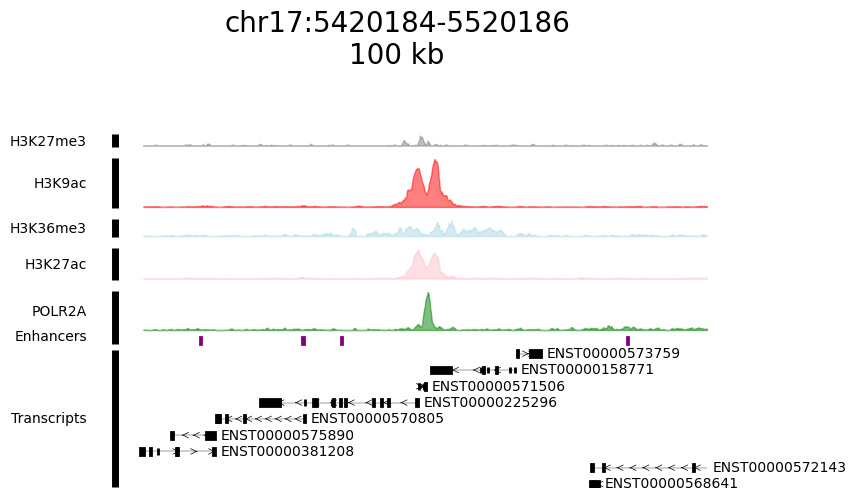

In [17]:
fig, ax = plt.subplots(figsize = (8,6))

chromosome = region['chr']
region_start = region['start']
region_end = region['end']

ax.set_ylim(ymin= -0.5, ymax  =340)
ax.set_xlim(xmin = (region_start  / 1000) - 10	,xmax = region_end  / 1000)
ax, parameter_list = plot_transcripts(ax = ax, region = region, transcript_annotation_df=longest_transcript_pr_gene_df, width_scalefactor=25, scalefactor=3, name = 'Transcripts')
ax, parameter_list = plot_features_from_bed(bed_df=enhancer_bed_file,ax=ax,parameter_list=parameter_list, region = region, name = 'Enhancers')
ax, parameter_list = add_hist_signal(ax = ax, hist_signal_in_region=sample1, region = region, parameter_list=parameter_list, color = 'green', name = 'POLR2A')
ax, parameter_list = add_hist_signal(ax = ax, hist_signal_in_region=sample2, region = region, parameter_list=parameter_list, color = 'pink', name = 'H3K27ac')
ax, parameter_list = add_hist_signal(ax = ax, hist_signal_in_region=sample3, region = region, parameter_list=parameter_list, color = 'lightblue', name = 'H3K36me3')
ax, parameter_list = add_hist_signal(ax = ax, hist_signal_in_region=sample4, region = region, parameter_list=parameter_list, color = 'red', name = 'H3K9ac')
ax, parameter_list = add_hist_signal(ax = ax, hist_signal_in_region=sample5, region = region, parameter_list=parameter_list, color = 'grey', name = 'H3K27me3')


ax.set_title(f'chr{chromosome}:{region_start}-{region_end}\n{(region_end - region_start) // 1000} kb',
        fontsize = 20,
        y=0.9)
ax.set_yticks([])
ax.set_xticks([])
# ax.set_xticks(list(range(region_start // 1000, (region_end // 1000) + (((region_end // 1000) - (region_start // 1000)) // 10), ((region_end // 1000) - (region_start // 1000)) // 10)))
plt.show()